# Data analysis: what actually drives subway delays?

Exploration to decide what the model should pay attention to.

**How to run:** select the `.venv` kernel (top right), then Run All, or Shift+Enter one cell at a time.

"Delay" everywhere below = the MTA posted a delay alert for that line during that hour. "Delay rate" = share of line-hours with one (~17% overall).

In [1]:
import sys
from pathlib import Path

# works from the repo root, from notebooks/, or as a script
ROOT = next(p for p in [Path.cwd(), Path.cwd().parent] if (p / "ml").exists())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ml import config
from ml.dataset import load_data
from ml.features import calendar_features, weather_features
from ml.plotting import GRAY, SEQ_CMAP, SERIES, TEXT_2, setup, show

setup()
pd.set_option("display.width", 160)

data = load_data()
alerts = pd.read_parquet(config.RAW_DIR / "alerts.parquet")
counts = data.counts                         # hours x lines, # of delay incidents
delayed = (counts > 0).astype(np.int8)       # hours x lines, 0/1
print(f"{len(counts):,} hours x {counts.shape[1]} lines, {counts.index[0]:%Y-%m-%d} -> {counts.index[-1]:%Y-%m-%d}")
print(f"overall delay rate: {delayed.to_numpy().mean():.1%}")

# long format: one row per (hour, line) with calendar + weather attached
long = delayed.stack().rename("delayed").reset_index()
long.columns = ["ts", "line", "delayed"]
long = pd.concat([long, calendar_features(long["ts"])], axis=1)
wx = weather_features(data.weather)
long = long.join(wx, on="ts")
# "expected" = this line's usual rate at this hour of this weekday. Comparing
# actual vs expected separates a real effect (e.g. rain) from time-of-day.
long["expected"] = long.groupby(["line", "dow", "hour"])["delayed"].transform("mean")


def lift_by(col_or_bins, data=long):
    """Actual delays / expected delays for each group. 1.0 = no effect."""
    g = data.groupby(col_or_bins, observed=True)
    return pd.DataFrame({
        "hours": g.size(),
        "delay_rate": g["delayed"].mean(),
        "lift": g["delayed"].sum() / g["expected"].sum(),
    })

49,176 hours x 22 lines, 2021-01-01 -> 2026-08-11
overall delay rate: 16.8%


## 1. Delays over time
Is the system getting better or worse? Is older data still representative?

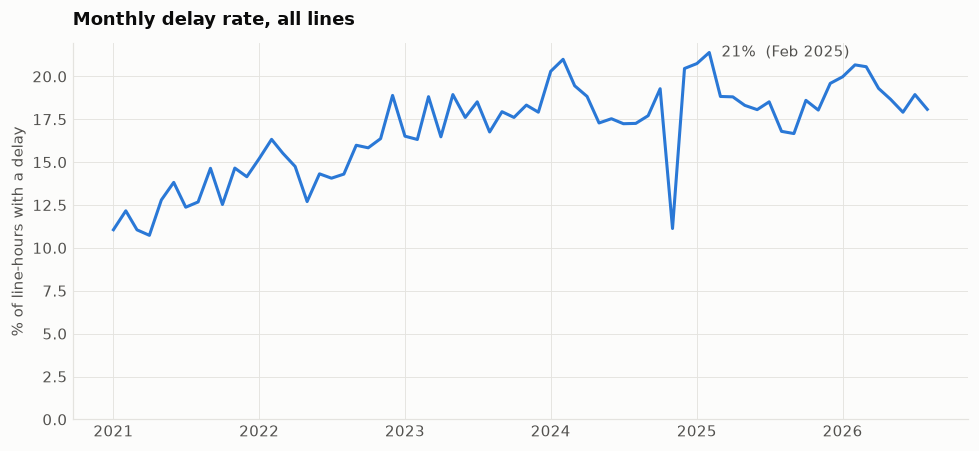

2021-01-01    12.7%
2022-01-01    15.4%
2023-01-01    17.6%
2024-01-01    18.1%
2025-01-01    18.7%
2026-01-01    19.3%
Freq: YS-JAN


In [2]:
monthly = delayed.resample("MS").mean().mean(axis=1)
fig, ax = plt.subplots()
ax.plot(monthly.index, monthly.values * 100, color=SERIES[0])
ax.set_ylim(0, None)
ax.set_ylabel("% of line-hours with a delay")
ax.set_title("Monthly delay rate, all lines")
peak = monthly.idxmax()
ax.annotate(f"{monthly.max():.0%}  ({peak:%b %Y})", (peak, monthly.max() * 100),
            xytext=(8, 0), textcoords="offset points", va="center", color=TEXT_2)
show(fig, "01_delays_over_time")
print(monthly.resample("YS").mean().map("{:.1%}".format).to_string())

## 2. Which lines are worst?

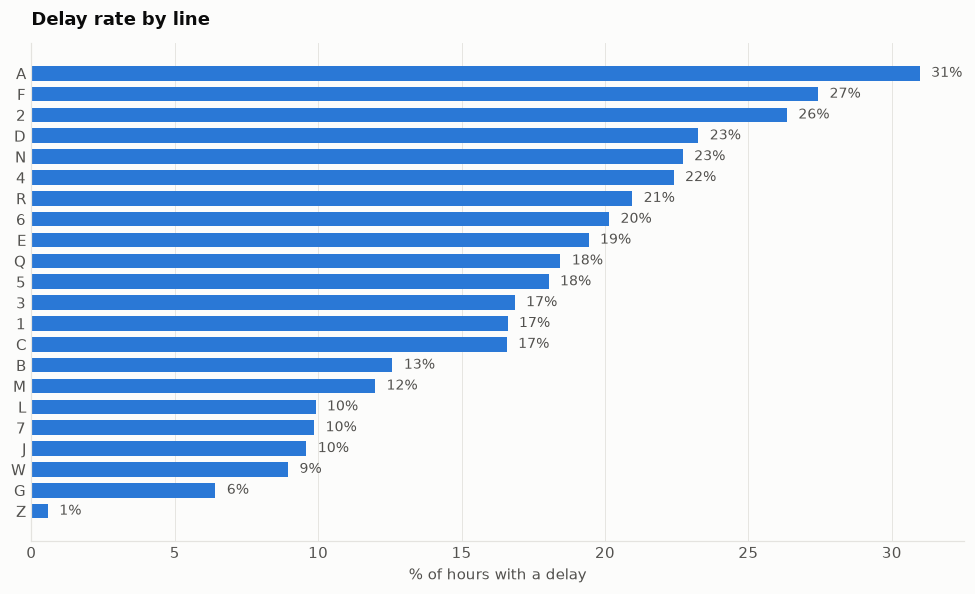

In [3]:
by_line = delayed.mean().sort_values()
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(by_line.index, by_line.values * 100, color=SERIES[0], height=0.7)
for y, v in enumerate(by_line.values):
    ax.text(v * 100 + 0.4, y, f"{v:.0%}", va="center", color=TEXT_2, fontsize=9)
ax.set_xlabel("% of hours with a delay")
ax.set_title("Delay rate by line")
ax.grid(axis="y", visible=False)
show(fig, "02_delay_rate_by_line")

## 3. When do delays happen? (hour x day of week)

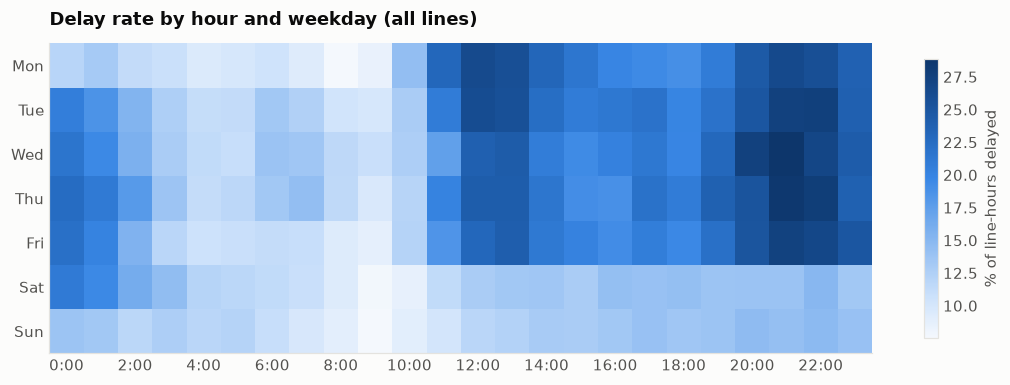

In [4]:
heat = long.pivot_table(index="dow", columns="hour", values="delayed", aggfunc="mean")
fig, ax = plt.subplots(figsize=(10, 3.6))
im = ax.imshow(heat.values * 100, cmap=SEQ_CMAP, aspect="auto")
ax.set_yticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax.set_xticks(range(0, 24, 2), [f"{h}:00" for h in range(0, 24, 2)])
ax.grid(False)
ax.set_title("Delay rate by hour and weekday (all lines)")
fig.colorbar(im, ax=ax, label="% of line-hours delayed", shrink=0.9)
show(fig, "03_hour_by_weekday")

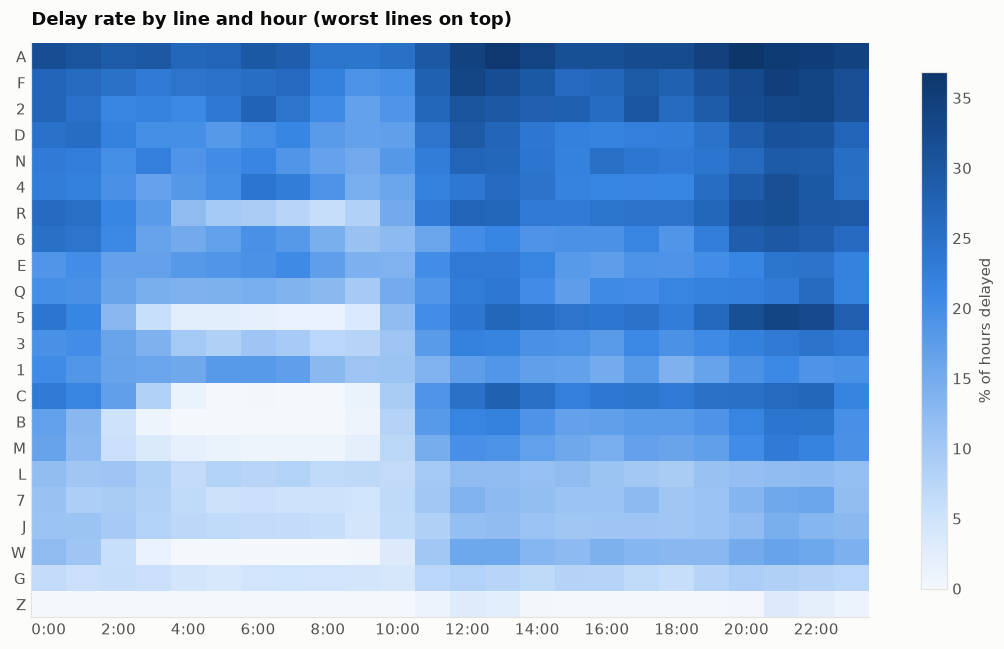

In [5]:
heat_line = long.pivot_table(index="line", columns="hour", values="delayed", aggfunc="mean")
heat_line = heat_line.loc[by_line.index[::-1]]  # worst line on top
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(heat_line.values * 100, cmap=SEQ_CMAP, aspect="auto")
ax.set_yticks(range(len(heat_line)), heat_line.index)
ax.set_xticks(range(0, 24, 2), [f"{h}:00" for h in range(0, 24, 2)])
ax.grid(False)
ax.set_title("Delay rate by line and hour (worst lines on top)")
fig.colorbar(im, ax=ax, label="% of hours delayed", shrink=0.9)
show(fig, "04_line_by_hour")

## 4. What causes delays?
Rough keyword categories from the alert text (first alert of each incident).

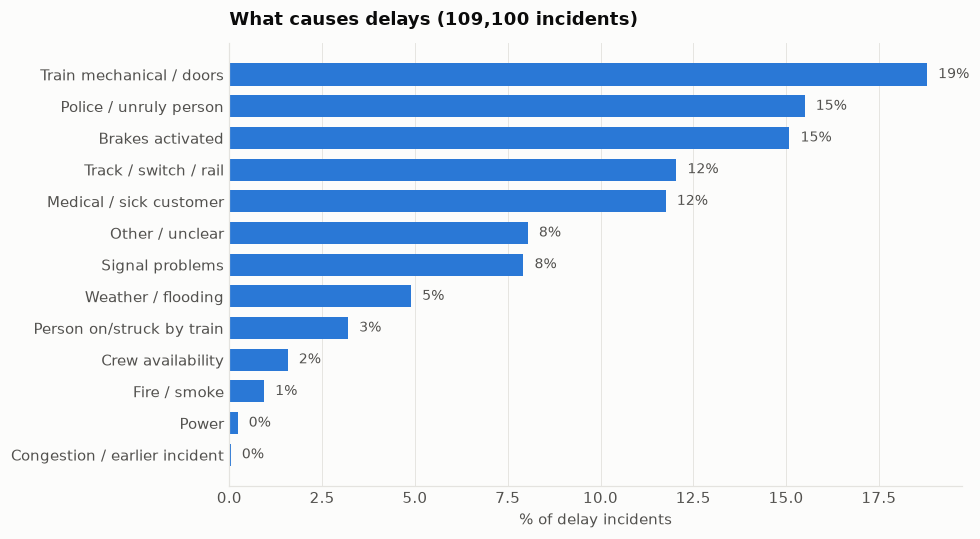

sample 'Other' headers:
20600     Brooklyn-bound F trains are getting back on sc...
52958     6 trains are delayed in both directions becaus...
116962    A Rockaway Park Shuttle trains are holding in ...
207768    Downtown F/M trains are delayed while we are u...
189514    A/Rockaway Park Shuttle trains are delayed in ...


In [6]:
CAUSES = [  # first match wins, so order matters
    ("Person on/struck by train", r"person on the track|someone on the track|people on the track|struck by|person was struck|unauthorized person"),
    ("Brakes activated", r"brake"),
    ("Signal problems", r"signal"),
    ("Medical / sick customer", r"sick|medical|ems|injured|needed help|customer who"),
    ("Police / unruly person", r"police|nypd|unruly|disruptive|dispute"),
    ("Train mechanical / doors", r"mechanical|door|train with a|disabled train|repair"),
    ("Track / switch / rail", r"track|switch|rail"),
    ("Power", r"power|electric"),
    ("Crew availability", r"crew|conductor|operator"),
    ("Fire / smoke", r"fire|smoke"),
    ("Weather / flooding", r"weather|snow|flood|water|heat|ice|wind|tree"),
    ("Congestion / earlier incident", r"earlier incident|congestion|volume|train traffic|delays in service"),
]
first = alerts.sort_values("update_number").drop_duplicates("event_id")
text = first["header"].fillna("").str.lower()
cause = pd.Series("Other / unclear", index=first.index)
for name, pattern in reversed(CAUSES):
    cause[text.str.contains(pattern, regex=True)] = name
cause_share = cause.value_counts(normalize=True).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(cause_share.index, cause_share.values * 100, color=SERIES[0], height=0.7)
for y, v in enumerate(cause_share.values):
    ax.text(v * 100 + 0.3, y, f"{v:.0%}", va="center", color=TEXT_2, fontsize=9)
ax.set_xlabel("% of delay incidents")
ax.set_title(f"What causes delays ({len(first):,} incidents)")
ax.grid(axis="y", visible=False)
show(fig, "05_causes")
print("sample 'Other' headers:")
print(first.loc[cause == "Other / unclear", "header"].sample(5, random_state=0).to_string())

## 5. Do delays cluster? (persistence)
If a line is delayed now, how likely is a delay k hours later? This is why
the model has "recent delays" features, and tells us how far back to look.

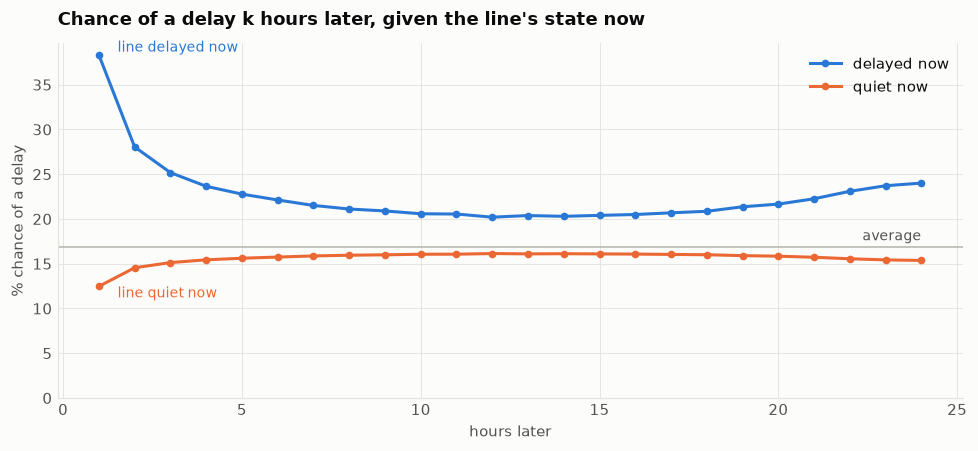

   after_delay after_quiet
1        38.3%       12.5%
2        28.0%       14.5%
3        25.2%       15.1%
6        22.1%       15.7%
12       20.2%       16.1%
24       24.0%       15.4%


In [7]:
B = delayed.to_numpy().astype(bool)
base = B.mean()
ks = np.arange(1, 25)
after_delay = [(B[:-k] & B[k:]).sum() / B[:-k].sum() for k in ks]
after_quiet = [(~B[:-k] & B[k:]).sum() / (~B[:-k]).sum() for k in ks]

fig, ax = plt.subplots()
ax.plot(ks, np.array(after_delay) * 100, color=SERIES[0], marker="o", markersize=4)
ax.plot(ks, np.array(after_quiet) * 100, color=SERIES[1], marker="o", markersize=4)
ax.axhline(base * 100, color=GRAY, linewidth=1)
ax.text(ks[-1], base * 100 + 0.8, "average", color=TEXT_2, ha="right", fontsize=9)
ax.text(ks[0] + 0.3, after_delay[0] * 100, "  line delayed now", color=SERIES[0], va="bottom", fontsize=9)
ax.text(ks[0] + 0.3, after_quiet[0] * 100, "  line quiet now", color=SERIES[1], va="top", fontsize=9)
ax.set_xlabel("hours later")
ax.set_ylabel("% chance of a delay")
ax.set_ylim(0, None)
ax.set_title("Chance of a delay k hours later, given the line's state now")
ax.legend(["delayed now", "quiet now"], loc="upper right")
show(fig, "06_persistence")
print(pd.DataFrame({"after_delay": after_delay, "after_quiet": after_quiet}, index=ks)
      .iloc[[0, 1, 2, 5, 11, 23]].map("{:.1%}".format).to_string())

## 6. Do delays spread between lines?
Lines sharing track (e.g. 2/3, N/Q/R/W, E/F) often get delayed together.
If this is strong, "is a neighboring line delayed right now?" is a good feature.

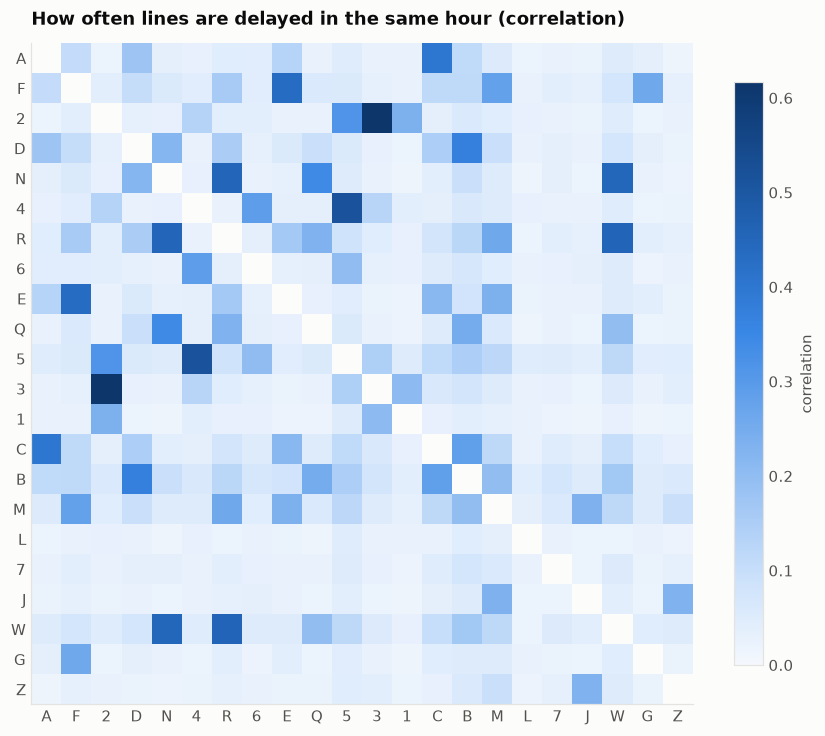

most linked line pairs:
line  line
2     3       0.62
4     5       0.51
R     W       0.45
N     R       0.45
      W       0.45
F     E       0.43
A     C       0.40
D     B       0.37
N     Q       0.34
2     5       0.31


In [8]:
corr = delayed.corr()
order = by_line.index[::-1]
corr = corr.loc[order, order]
fig, ax = plt.subplots(figsize=(8, 7))
masked = np.where(np.eye(len(corr), dtype=bool), np.nan, corr.values)
im = ax.imshow(masked, cmap=SEQ_CMAP, vmin=0, vmax=np.nanmax(masked))
ax.set_xticks(range(len(corr)), corr.columns)
ax.set_yticks(range(len(corr)), corr.index)
ax.grid(False)
ax.set_title("How often lines are delayed in the same hour (correlation)")
fig.colorbar(im, ax=ax, label="correlation", shrink=0.8)
show(fig, "07_line_correlation")
pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), 1)).stack().sort_values(ascending=False)
print("most linked line pairs:")
print(pairs.head(10).round(2).to_string())

## 7. Weather
"Lift" = actual delays / expected for that line and hour of the week.
1.0 = weather makes no difference; 1.3 = 30% more delays than usual.

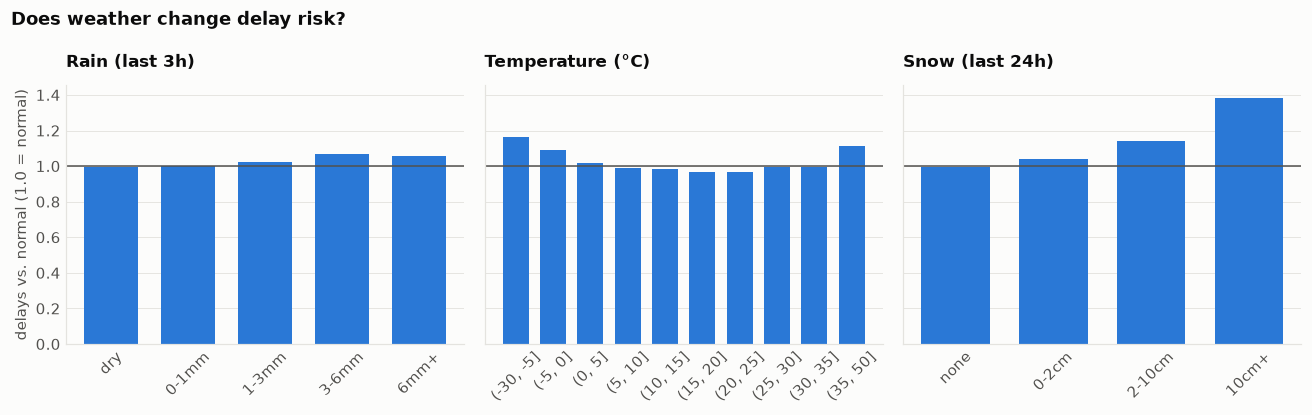


rain:
             hours delay_rate  lift
precip_3h                         
dry        852896      16.7%  0.99
0-1mm      126148      17.1%  1.00
1-3mm       53768      17.4%  1.02
3-6mm       27764      17.7%  1.07
6mm+        21296      17.7%  1.06

temperature:
                  hours delay_rate  lift
temperature_2m                         
(-30, -5]        36234      17.2%  1.16
(-5, 0]          94666      17.2%  1.09
(0, 5]          155562      16.9%  1.02
(5, 10]         159962      16.6%  0.99
(10, 15]        154704      16.3%  0.98
(15, 20]        166914      16.1%  0.97
(20, 25]        184470      16.5%  0.97
(25, 30]        100276      18.3%  0.99
(30, 35]         26290      19.2%  0.99
(35, 50]          2794      23.0%  1.11

snow:
             hours delay_rate  lift
snow_24h                          
none      1007600      16.7%  0.99
0-2cm       55990      17.6%  1.04
2-10cm      15356      17.7%  1.14
10cm+        2926      22.7%  1.39


In [9]:
precip = lift_by(pd.cut(long["precip_3h"], [-0.1, 0, 1, 3, 6, 100],
                        labels=["dry", "0-1mm", "1-3mm", "3-6mm", "6mm+"]))
temp = lift_by(pd.cut(long["temperature_2m"], [-30, -5, 0, 5, 10, 15, 20, 25, 30, 35, 50]))
snow = lift_by(pd.cut(long["snow_24h"], [-0.1, 0, 2, 10, 200], labels=["none", "0-2cm", "2-10cm", "10cm+"]))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax, (title, tbl) in zip(axes, [("Rain (last 3h)", precip), ("Temperature (°C)", temp), ("Snow (last 24h)", snow)]):
    labels = [str(i) for i in tbl.index]
    ax.bar(labels, tbl["lift"], color=SERIES[0], width=0.7)
    ax.axhline(1, color=TEXT_2, linewidth=1)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("delays vs. normal (1.0 = normal)")
fig.suptitle("Does weather change delay risk?", x=0.01, ha="left", fontweight="bold")
show(fig, "08_weather")
for name, tbl in [("rain", precip), ("temperature", temp), ("snow", snow)]:
    print(f"\n{name}:\n", tbl.assign(delay_rate=tbl["delay_rate"].map("{:.1%}".format),
                                   lift=tbl["lift"].round(2)).to_string())

## 8. Crowding (from the ridership dataset)
Do lines have more delays at the hours they're most crowded?

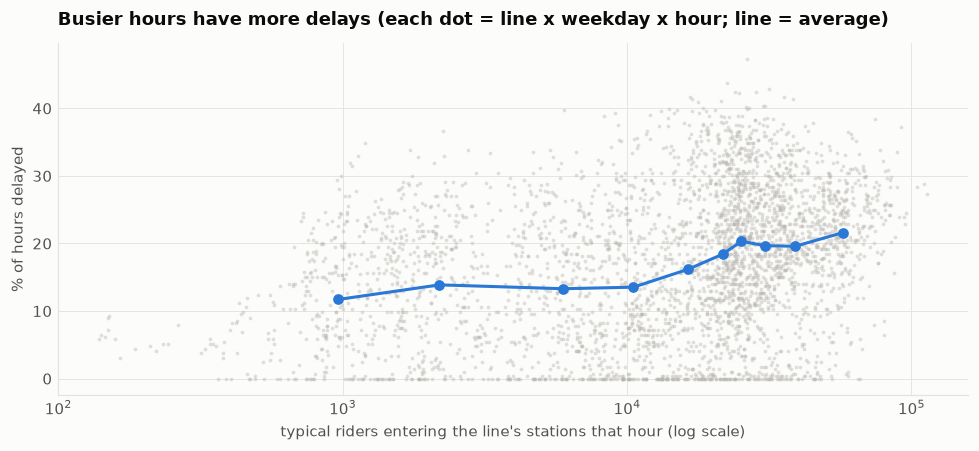

rank correlation, all points: 0.32
median within-line correlation: 0.19  (is it crowding, or just time of day?)


In [10]:
lp = data.line_profile
rates = long.groupby(["line", "dow", "hour"], observed=True)["delayed"].mean().rename("rate").reset_index()
crowd = rates.merge(lp, on=["line", "dow", "hour"])
crowd["riders_bin"] = pd.qcut(crowd["line_riders"], 10)
binned = crowd.groupby("riders_bin", observed=True).agg(riders=("line_riders", "median"), rate=("rate", "mean"))

fig, ax = plt.subplots()
ax.scatter(crowd["line_riders"], crowd["rate"] * 100, s=6, color=GRAY, alpha=0.4, linewidths=0)
ax.plot(binned["riders"], binned["rate"] * 100, color=SERIES[0], marker="o")
ax.set_xscale("symlog", linthresh=100)
ax.set_xlabel("typical riders entering the line's stations that hour (log scale)")
ax.set_ylabel("% of hours delayed")
ax.set_title("Busier hours have more delays (each dot = line x weekday x hour; line = average)")
show(fig, "09_crowding")
within = crowd.groupby("line")[["line_riders", "rate"]].corr(method="spearman").xs("rate", level=1)["line_riders"]
print(f"rank correlation, all points: {crowd[['line_riders', 'rate']].corr('spearman').iloc[0, 1]:.2f}")
print(f"median within-line correlation: {within.median():.2f}  (is it crowding, or just time of day?)")

## 9. Calendar effects: month, weekends, holidays

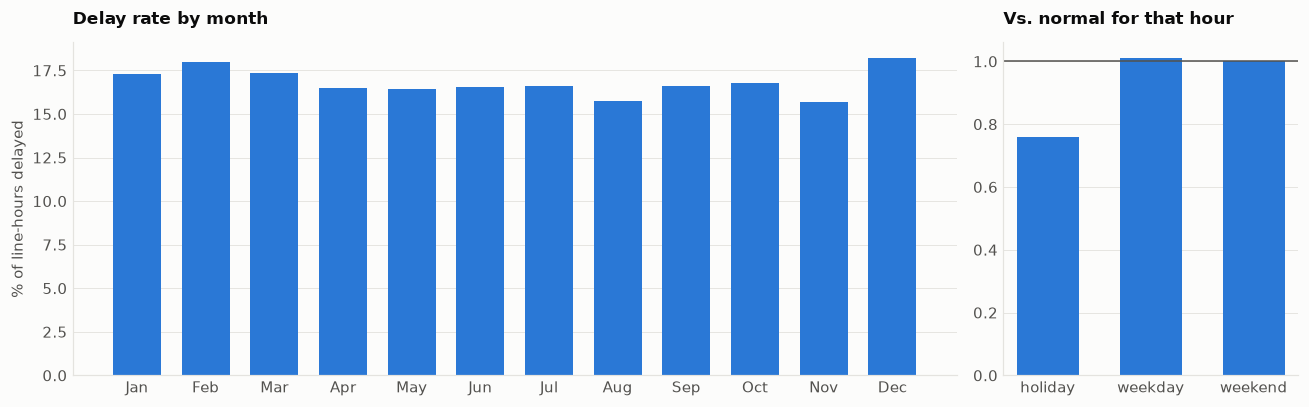

          hours  delay_rate  lift
holiday   32208       0.136  0.76
weekday  740256       0.187  1.01
weekend  309408       0.128  1.00


In [11]:
month = lift_by("month")
daytype = lift_by(np.select([long["is_holiday"] == 1, long["is_weekend"] == 1], ["holiday", "weekend"], "weekday"))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [3, 1]})
axes[0].bar(month.index, month["delay_rate"] * 100, color=SERIES[0], width=0.7)
axes[0].set_xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
axes[0].set_title("Delay rate by month", fontsize=11)
axes[0].set_ylabel("% of line-hours delayed")
axes[1].bar(daytype.index, daytype["lift"], color=SERIES[0], width=0.6)
axes[1].axhline(1, color=TEXT_2, linewidth=1)
axes[1].set_title("Vs. normal for that hour", fontsize=11)
for ax in axes:
    ax.grid(axis="x", visible=False)
show(fig, "10_calendar")
print(daytype.round(3).to_string())

## 10. Is the future like the past? (drift)
The model trains on 2021-Jul 2025 and is tested on Aug 2025 onward. If line
delay rates shifted a lot, older training data is less useful.

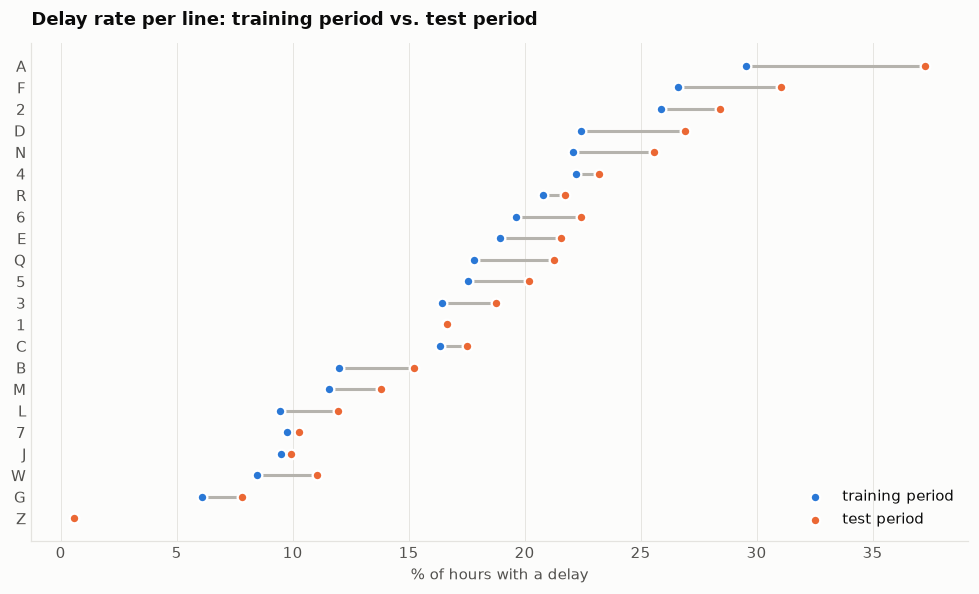

      train  test  change
line                     
Z       0.6   0.6     0.0
1      16.6  16.7     0.1
J       9.5   9.9     0.4
7       9.8  10.3     0.5
R      20.8  21.7     0.9
4      22.2  23.2     1.0
C      16.4  17.5     1.1
G       6.1   7.8     1.7
M      11.6  13.8     2.2
3      16.4  18.8     2.4
2      25.9  28.4     2.5
W       8.5  11.1     2.6
L       9.4  12.0     2.6
5      17.5  20.2     2.7
E      18.9  21.6     2.7
6      19.6  22.4     2.8
B      12.0  15.2     3.2
Q      17.8  21.3     3.5
N      22.1  25.6     3.5
D      22.4  26.9     4.5
F      26.6  31.1     4.5
A      29.6  37.3     7.7


In [12]:
split = pd.Timestamp(config.TEST_START)
before = delayed[delayed.index < split].mean()
after = delayed[delayed.index >= split].mean()
drift = pd.DataFrame({"train": before, "test": after}).loc[by_line.index]
fig, ax = plt.subplots(figsize=(9, 5.5))
y = np.arange(len(drift))
ax.hlines(y, drift.min(axis=1) * 100, drift.max(axis=1) * 100, color=GRAY, linewidth=2)
ax.scatter(drift["train"] * 100, y, color=SERIES[0], s=40, zorder=3, label="training period",
           edgecolors="white", linewidths=1.5)
ax.scatter(drift["test"] * 100, y, color=SERIES[1], s=40, zorder=3, label="test period",
           edgecolors="white", linewidths=1.5)
ax.set_yticks(y, drift.index)
ax.set_xlabel("% of hours with a delay")
ax.set_title("Delay rate per line: training period vs. test period")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
show(fig, "11_drift")
print((drift * 100).round(1).assign(change=lambda d: (d.test - d.train).round(1)).sort_values("change").to_string())